<a href="https://colab.research.google.com/github/beingAnujChaudhary/DSFS-Joel-Grus/blob/main/notebooks/chapter_06_probability/06_probability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

# Mount Google Drive (optional)
drive.mount('/content/drive')

# Clone your GitHub repository
!git clone https://github.com/beingAnujChaudhary/DSFS-Joel-Grus.git

# Move into repository
%cd /content/DSFS-Joel-Grus

# Move into Chapter 1 folder
%cd notebooks/chapter_06_probability

Mounted at /content/drive
Cloning into 'DSFS-Joel-Grus'...
remote: Enumerating objects: 237, done.
remote: Counting objects: 100% (237/237), done.
remote: Compressing objects: 100% (163/163), done.
remote: Total 237 (delta 150), reused 109 (delta 72), pack-reused 0 (from 0)
Receiving objects: 100% (237/237), 2.14 MiB | 10.60 MiB/s, done.
Resolving deltas: 100% (150/150), done.
/content/DSFS-Joel-Grus
/content/DSFS-Joel-Grus/notebooks/chapter_06_probability



# Chapter 6: Probability

**Book**: *Data Science from Scratch* by Joel Grus  
**Focus**: Quantifying uncertainty, conditional probability, Bayes's Theorem, and continuous distributions

## Purpose

This notebook contains my implementation and understanding of Chapter 6. We'll simulate conditional probability paradoxes, apply Bayes's Theorem to avoid the base-rate fallacy, and build continuous distributions from scratch to understand the Central Limit Theorem.

> 💡 **Why from scratch?** Libraries like `scipy.stats` have these distributions built-in. Building the PDF, CDF, and inverse CDF manually reveals how probability mass is calculated and how algorithms (like binary search) solve mathematical roadblocks.

### Goals

By the end of this chapter, I should understand:
- Probability basics and randomness
- Events, sample spaces, and probability calculations
- Conditional probability and independence
- Bayes's Theorem and the base rate fallacy
- Random variables and expected value
- Continuous distributions (Uniform, Normal)
- The Central Limit Theorem
- Why probability matters in machine learning

### Key lesson

> Probability helps us reason under uncertainty. It doesn't give absolute truth — it gives a structured way to quantify what we don't know.

### Important learning strategy

Do not memorise formulas. Ask:

> *What uncertainty is this helping me reason about?*

---

In [2]:
## Environment Setup

import math
import random
from collections import Counter
import matplotlib.pyplot as plt

# Set random seed for reproducibility
random.seed(42)

print("✅ Chapter 6 environment ready!")


✅ Chapter 6 environment ready!


---

## 1. Randomness and Coin Flips

Probability starts with randomness. Let's simulate coin flips to build intuition.


In [3]:
# Single coin flip
coin = random.choice(["Heads", "Tails"])
print(f"Single flip: {coin}")

# Multiple coin flips
heads = 0
tails = 0

for _ in range(1000):
    flip = random.choice(["Heads", "Tails"])
    if flip == "Heads":
        heads += 1
    else:
        tails += 1

print(f"\nAfter 1000 flips:")
print(f"  Heads: {heads} ({heads/10:.1f}%)")
print(f"  Tails: {tails} ({tails/10:.1f}%)")


Single flip: Heads

After 1000 flips:
  Heads: 486 (48.6%)
  Tails: 514 (51.4%)


### 💡 Reflection
- Why do we call this random?
- Why do results become closer to 50/50 after many flips? (Law of Large Numbers)

---

## 2. Sample Space and Events

A **sample space** contains all possible outcomes. An **event** is a subset of outcomes.


In [4]:
# Sample space for a die
dice_sample_space = [1, 2, 3, 4, 5, 6]
print(f"Sample space: {dice_sample_space}")

# Event: rolling an even number
even_numbers = [2, 4, 6]
probability_even = len(even_numbers) / len(dice_sample_space)
print(f"\nEvent: rolling an even number")
print(f"  Favorable outcomes: {even_numbers}")
print(f"  Probability: {probability_even} = {probability_even:.2%}")

# Event: rolling a number greater than 4
high_numbers = [5, 6]
probability_high = len(high_numbers) / len(dice_sample_space)
print(f"\nEvent: rolling > 4")
print(f"  Favorable outcomes: {high_numbers}")
print(f"  Probability: {probability_high} = {probability_high:.2%}")


Sample space: [1, 2, 3, 4, 5, 6]

Event: rolling an even number
  Favorable outcomes: [2, 4, 6]
  Probability: 0.5 = 50.00%

Event: rolling > 4
  Favorable outcomes: [5, 6]
  Probability: 0.3333333333333333 = 33.33%


### 💡 Reflection
- Why is probability always between 0 and 1?
- What does P(event) = 0 mean? P(event) = 1?

---

## 3. Simulating Dice Rolls

Let's verify that each face appears roughly equally over many rolls.


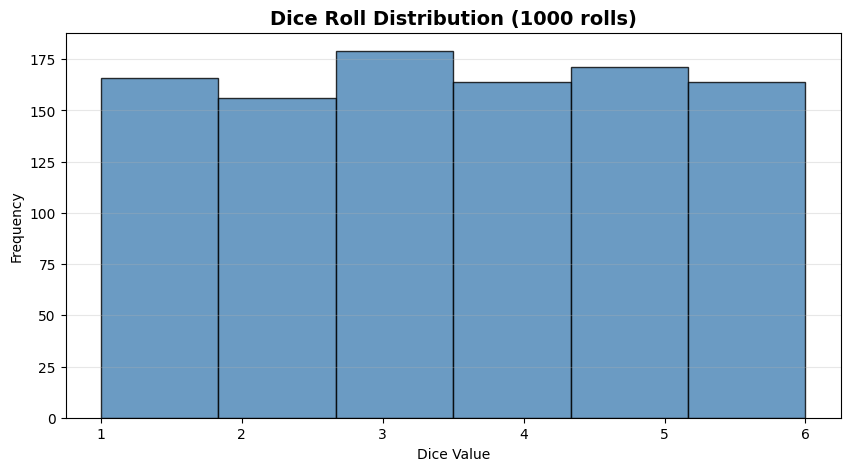

Frequency of each value:
  1: 166 times (16.6%)
  2: 156 times (15.6%)
  3: 179 times (17.9%)
  4: 164 times (16.4%)
  5: 171 times (17.1%)
  6: 164 times (16.4%)


In [5]:
rolls = [random.randint(1, 6) for _ in range(1000)]

plt.figure(figsize=(10, 5))
plt.hist(rolls, bins=6, edgecolor='black', color='steelblue', alpha=0.8)
plt.title("Dice Roll Distribution (1000 rolls)", fontsize=14, fontweight='bold')
plt.xlabel("Dice Value")
plt.ylabel("Frequency")
plt.xticks([1, 2, 3, 4, 5, 6])
plt.grid(axis='y', alpha=0.3)
plt.show()

# Count frequencies
counts = Counter(rolls)
print("Frequency of each value:")
for face in sorted(counts.keys()):
    print(f"  {face}: {counts[face]} times ({counts[face]/10:.1f}%)")


### 💡 Reflection
- Why do all numbers appear roughly equally?
- What would happen with only 10 rolls? 100,000 rolls?

---

## 4. Conditional Probability

Conditional probability means **probability after new information appears**.


In [6]:
# Prior probabilities
probability_rain = 0.30
probability_rain_given_clouds = 0.70

print("Rain probabilities:")
print(f"  P(Rain) = {probability_rain:.0%}")
print(f"  P(Rain | Clouds) = {probability_rain_given_clouds:.0%}")
print(f"\n  → Seeing clouds increases rain probability!")
print(f"  → New evidence updates our beliefs")


Rain probabilities:
  P(Rain) = 30%
  P(Rain | Clouds) = 70%

  → Seeing clouds increases rain probability!
  → New evidence updates our beliefs


### The Boy/Girl Paradox (Monte Carlo Simulation)



In [7]:
def random_kid():
    return random.choice(["boy", "girl"])

both_girls = 0
older_girl = 0
either_girl = 0

random.seed(0)
for _ in range(10000):
    younger = random_kid()
    older = random_kid()

    if older == "girl":
        older_girl += 1
    if older == "girl" and younger == "girl":
        both_girls += 1
    if older == "girl" or younger == "girl":
        either_girl += 1

print("\nBoy/Girl Paradox:")
print(f"  P(both girls | older is girl):     {both_girls / older_girl:.3f}  (≈ 1/2)")
print(f"  P(both girls | at least one girl): {both_girls / either_girl:.3f}  (≈ 1/3)")
print(f"\n  → The condition matters! 'At least one' gives different probability than 'older is'.")



Boy/Girl Paradox:
  P(both girls | older is girl):     0.501  (≈ 1/2)
  P(both girls | at least one girl): 0.331  (≈ 1/3)

  → The condition matters! 'At least one' gives different probability than 'older is'.


### 💡 Reflection
- Why does additional information change probability?
- Why do the two conditions give different answers?

---

## 5. Independent Events

Independent events do not affect each other.


In [8]:
# Coin flips are independent
flip_1 = random.choice(["Heads", "Tails"])
flip_2 = random.choice(["Heads", "Tails"])

print(f"Flip 1: {flip_1}")
print(f"Flip 2: {flip_2}")
print(f"\nDoes Flip 1 affect Flip 2? No — they're independent!")

# Demonstrate independence over many trials
both_heads = 0
first_heads_second_heads = 0
first_heads = 0

for _ in range(10000):
    f1 = random.choice(["Heads", "Tails"])
    f2 = random.choice(["Heads", "Tails"])

    if f1 == "Heads":
        first_heads += 1
        if f2 == "Heads":
            first_heads_second_heads += 1
    if f1 == "Heads" and f2 == "Heads":
        both_heads += 1

print(f"\nVerification of independence:")
print(f"  P(Heads on 2nd | Heads on 1st) = {first_heads_second_heads/first_heads:.3f}")
print(f"  P(Heads on 2nd) = 0.500")
print(f"  → They're equal, confirming independence!")


Flip 1: Tails
Flip 2: Heads

Does Flip 1 affect Flip 2? No — they're independent!

Verification of independence:
  P(Heads on 2nd | Heads on 1st) = 0.506
  P(Heads on 2nd) = 0.500
  → They're equal, confirming independence!


### 💡 Reflection
- What would make events dependent? (Example: drawing cards without replacement)

---

## 6. Bayes's Theorem & The Medical Test Paradox

Bayes's Theorem reverses conditional probabilities. This reveals the **base rate fallacy**.



In [9]:
def bayes_theorem(p_e, p_f_given_e, p_f_given_not_e):
    """Calculates P(E|F) using Bayes's Theorem.

    P(E|F) = P(F|E) * P(E) / P(F)
    where P(F) = P(F|E)*P(E) + P(F|¬E)*P(¬E)
    """
    p_not_e = 1 - p_e
    p_f = p_f_given_e * p_e + p_f_given_not_e * p_not_e
    return (p_f_given_e * p_e) / p_f

# Medical Test Parameters
p_disease = 0.0001                 # 1 in 10,000 have the disease
p_positive_given_disease = 0.99    # 99% true positive rate
p_positive_given_healthy = 0.01    # 1% false positive rate

p_disease_given_positive = bayes_theorem(
    p_disease,
    p_positive_given_disease,
    p_positive_given_healthy
)

print("=" * 50)
print("MEDICAL TEST PARADOX")
print("=" * 50)
print(f"\nGiven:")
print(f"  Disease prevalence: {p_disease:.4f} ({p_disease*100:.2f}%)")
print(f"  Test accuracy (true positive): {p_positive_given_disease:.0%}")
print(f"  False positive rate: {p_positive_given_healthy:.0%}")
print(f"\nResult:")
print(f"  P(Disease | Positive Test) = {p_disease_given_positive:.4f}")
print(f"  That's only {p_disease_given_positive*100:.2f}%!")
print(f"\n🔍 Why? Because the disease is so rare, false positives")
print(f"   from healthy people vastly outnumber true positives.")


MEDICAL TEST PARADOX

Given:
  Disease prevalence: 0.0001 (0.01%)
  Test accuracy (true positive): 99%
  False positive rate: 1%

Result:
  P(Disease | Positive Test) = 0.0098
  That's only 0.98%!

🔍 Why? Because the disease is so rare, false positives
   from healthy people vastly outnumber true positives.


### 💡 Reflection
- Why does evidence change our beliefs?
- Why is the base rate (prior probability) so important?
- How does this apply to spam filtering? Fraud detection?

---

## 7. Expected Value

Expected value is the **long-run average outcome**.


In [10]:
# Expected value of a fair die
dice_values = [1, 2, 3, 4, 5, 6]
expected_value = sum(dice_values) / len(dice_values)

print(f"Expected value of a fair die: {expected_value}")
print(f"  → Even though 3.5 never appears on a single roll,")
print(f"    it's the long-run average!")

# Simulate to verify
num_rolls = 100000
total = 0
for _ in range(num_rolls):
    total += random.randint(1, 6)

average = total / num_rolls
print(f"\nAfter {num_rolls:,} rolls: average = {average:.3f}")
print(f"  → Converges to expected value of {expected_value}")


Expected value of a fair die: 3.5
  → Even though 3.5 never appears on a single roll,
    it's the long-run average!

After 100,000 rolls: average = 3.489
  → Converges to expected value of 3.5


### 💡 Reflection
- Why is expected value 3.5 even though it never appears on a die?
- How is expected value used in decision making? Reinforcement learning?

---

## 8. Continuous Distributions: The Uniform Distribution

For continuous outcomes, probability comes from **areas under curves**, not individual points.


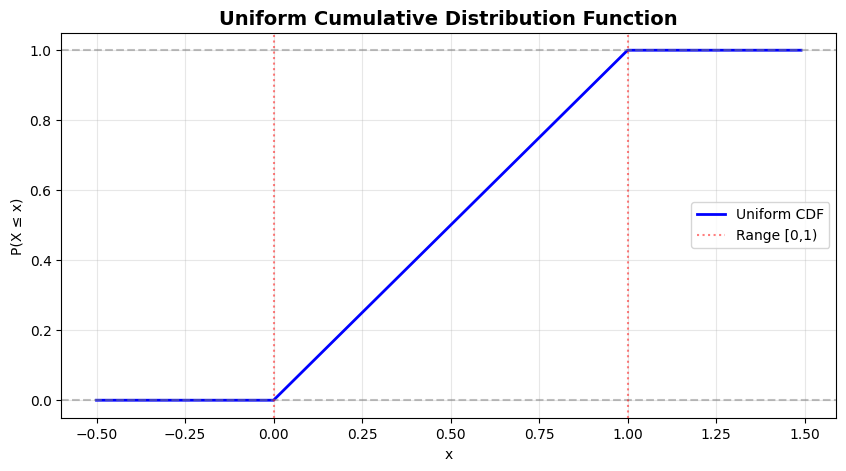

Uniform distribution examples:
  P(X ≤ 0.25) = 0.25
  P(X ≤ 0.50) = 0.5
  P(X ≤ 0.75) = 0.75


In [11]:
def uniform_pdf(x):
    return 1 if 0 <= x < 1 else 0

def uniform_cdf(x):
    """Returns the probability that a uniform random variable is <= x"""
    if x < 0:   return 0    # Not yet in range
    elif x < 1: return x    # e.g., P(X <= 0.4) = 0.4
    else:       return 1    # Past the range

# Plot Uniform CDF
xs = [x / 100.0 for x in range(-50, 150)]
ys = [uniform_cdf(x) for x in xs]

plt.figure(figsize=(10, 5))
plt.plot(xs, ys, 'b-', linewidth=2, label='Uniform CDF')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='red', linestyle=':', alpha=0.5, label='Range [0,1)')
plt.axvline(x=1, color='red', linestyle=':', alpha=0.5)
plt.legend()
plt.title("Uniform Cumulative Distribution Function", fontsize=14, fontweight='bold')
plt.xlabel("x")
plt.ylabel("P(X ≤ x)")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Uniform distribution examples:")
print(f"  P(X ≤ 0.25) = {uniform_cdf(0.25)}")
print(f"  P(X ≤ 0.50) = {uniform_cdf(0.50)}")
print(f"  P(X ≤ 0.75) = {uniform_cdf(0.75)}")


---

## 9. The Normal (Gaussian) Distribution

The "king of distributions" — a bell-shaped curve defined by mean (μ) and standard deviation (σ).


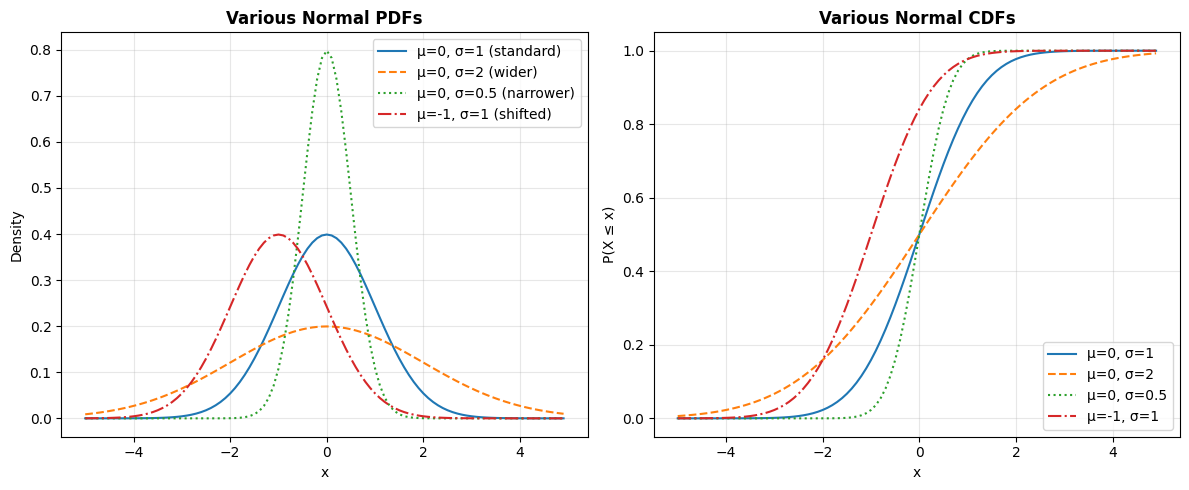

Normal distribution key facts:
  ~68% of values within ±1σ:  P(-1 < Z < 1) = 0.683
  ~95% of values within ±2σ:  P(-2 < Z < 2) = 0.954
  ~99.7% of values within ±3σ: P(-3 < Z < 3) = 0.997


In [12]:
def normal_pdf(x, mu=0, sigma=1):
    sqrt_two_pi = math.sqrt(2 * math.pi)
    return (math.exp(-(x - mu) ** 2 / 2 / sigma ** 2) / (sqrt_two_pi * sigma))

def normal_cdf(x, mu=0, sigma=1):
    return (1 + math.erf((x - mu) / math.sqrt(2) / sigma)) / 2

# Plot various Normal PDFs
xs = [x / 10.0 for x in range(-50, 50)]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(xs, [normal_pdf(x, sigma=1) for x in xs], '-', label='μ=0, σ=1 (standard)')
plt.plot(xs, [normal_pdf(x, sigma=2) for x in xs], '--', label='μ=0, σ=2 (wider)')
plt.plot(xs, [normal_pdf(x, sigma=0.5) for x in xs], ':', label='μ=0, σ=0.5 (narrower)')
plt.plot(xs, [normal_pdf(x, mu=-1) for x in xs], '-.', label='μ=-1, σ=1 (shifted)')
plt.legend()
plt.title("Various Normal PDFs", fontweight='bold')
plt.xlabel("x")
plt.ylabel("Density")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(xs, [normal_cdf(x, sigma=1) for x in xs], '-', label='μ=0, σ=1')
plt.plot(xs, [normal_cdf(x, sigma=2) for x in xs], '--', label='μ=0, σ=2')
plt.plot(xs, [normal_cdf(x, sigma=0.5) for x in xs], ':', label='μ=0, σ=0.5')
plt.plot(xs, [normal_cdf(x, mu=-1) for x in xs], '-.', label='μ=-1, σ=1')
plt.legend(loc='lower right')
plt.title("Various Normal CDFs", fontweight='bold')
plt.xlabel("x")
plt.ylabel("P(X ≤ x)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Key probabilities
print("Normal distribution key facts:")
print(f"  ~68% of values within ±1σ:  P(-1 < Z < 1) = {normal_cdf(1) - normal_cdf(-1):.3f}")
print(f"  ~95% of values within ±2σ:  P(-2 < Z < 2) = {normal_cdf(2) - normal_cdf(-2):.3f}")
print(f"  ~99.7% of values within ±3σ: P(-3 < Z < 3) = {normal_cdf(3) - normal_cdf(-3):.3f}")



---

## 10. Inverting the Normal CDF (Binary Search)

When the Normal CDF has no closed-form inverse, **binary search** solves the problem numerically.


In [13]:
def inverse_normal_cdf(p, mu=0, sigma=1, tolerance=0.00001):
    """Find approximate inverse using binary search."""
    if mu != 0 or sigma != 1:
        return mu + sigma * inverse_normal_cdf(p, tolerance=tolerance)

    low_z, low_p = -10.0, 0            # normal_cdf(-10) ≈ 0
    hi_z, hi_p   =  10.0, 1            # normal_cdf(10)  ≈ 1

    while hi_z - low_z > tolerance:
        mid_z = (low_z + hi_z) / 2     # Consider midpoint
        mid_p = normal_cdf(mid_z)      # CDF value at midpoint

        if mid_p < p:
            low_z, low_p = mid_z, mid_p   # Search above
        elif mid_p > p:
            hi_z, hi_p = mid_z, mid_p     # Search below
        else:
            break

    return mid_z

# Test
print("Inverse Normal CDF (z-scores):")
print(f"  50th percentile (median): {inverse_normal_cdf(0.50):.4f}")
print(f"  90th percentile: {inverse_normal_cdf(0.90):.4f}")
print(f"  95th percentile: {inverse_normal_cdf(0.95):.4f}")
print(f"  99th percentile: {inverse_normal_cdf(0.99):.4f}")
print(f"  99.9th percentile: {inverse_normal_cdf(0.999):.4f}")

print(f"\n🔍 When math doesn't provide a clean formula,")
print(f"   computer science (algorithms) solves the problem!")


Inverse Normal CDF (z-scores):
  50th percentile (median): 0.0000
  90th percentile: 1.2816
  95th percentile: 1.6448
  99th percentile: 2.3263
  99.9th percentile: 3.0902

🔍 When math doesn't provide a clean formula,
   computer science (algorithms) solves the problem!


---

## 11. The Central Limit Theorem (CLT)

The CLT states that the average of many independent random variables approaches a Normal distribution — regardless of the original distribution.


Central Limit Theorem in action:
Binomial(100, 0.75) ≈ Normal(μ=75, σ≈4.33)


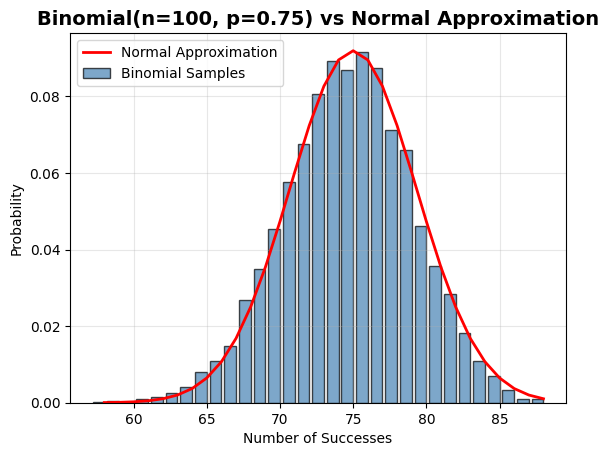


Binomial(50, 0.5) ≈ Normal(μ=25, σ≈3.54)


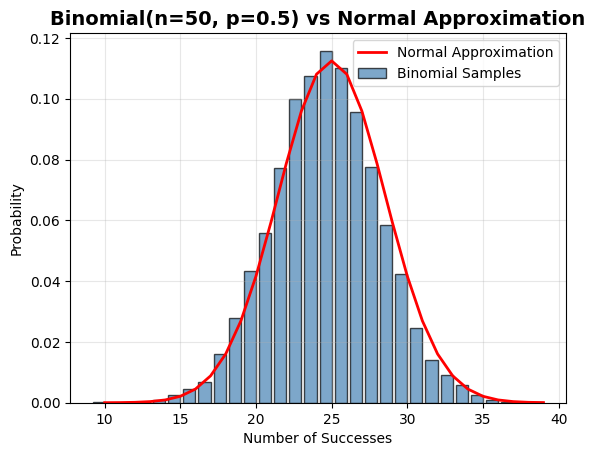

In [14]:
def bernoulli_trial(p):
    return 1 if random.random() < p else 0

def binomial(n, p):
    return sum(bernoulli_trial(p) for _ in range(n))

def make_hist(p, n, num_points):
    """Compare Binomial distribution with Normal approximation."""
    data = [binomial(n, p) for _ in range(num_points)]

    # Bar chart for binomial samples
    histogram = Counter(data)
    plt.bar([x - 0.4 for x in histogram.keys()],
            [v / num_points for v in histogram.values()],
            0.8,
            color='steelblue',
            alpha=0.7,
            edgecolor='black',
            label='Binomial Samples')

    # Normal approximation
    mu = p * n
    sigma = math.sqrt(n * p * (1 - p))

    xs = range(min(data), max(data) + 1)
    ys = [normal_cdf(i + 0.5, mu, sigma) - normal_cdf(i - 0.5, mu, sigma)
          for i in xs]
    plt.plot(xs, ys, 'r-', linewidth=2, label='Normal Approximation')

    plt.title(f"Binomial(n={n}, p={p}) vs Normal Approximation", fontsize=14, fontweight='bold')
    plt.xlabel("Number of Successes")
    plt.ylabel("Probability")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Visualize CLT
print("Central Limit Theorem in action:")
print("Binomial(100, 0.75) ≈ Normal(μ=75, σ≈4.33)")
make_hist(0.75, 100, 10000)

# Demonstrate with different parameters
print("\nBinomial(50, 0.5) ≈ Normal(μ=25, σ≈3.54)")
make_hist(0.5, 50, 10000)


### 💡 Reflection
- Why does the CLT matter for A/B testing?
- Why are sample means approximately Normal even when the data isn't?

---

## 12. Probability Distributions Visualization



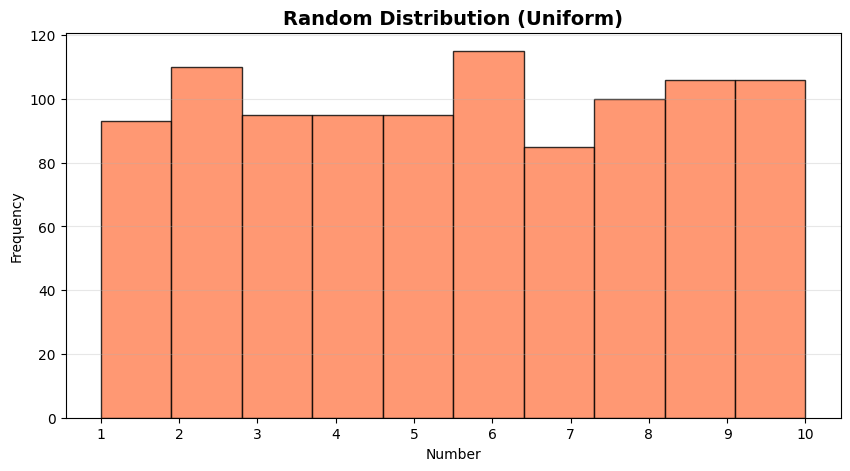

In [15]:
# Generate random numbers from uniform distribution
random_numbers = [random.randint(1, 10) for _ in range(1000)]

plt.figure(figsize=(10, 5))
plt.hist(random_numbers, bins=10, edgecolor='black', color='coral', alpha=0.8)
plt.title("Random Distribution (Uniform)", fontsize=14, fontweight='bold')
plt.xlabel("Number")
plt.ylabel("Frequency")
plt.xticks(range(1, 11))
plt.grid(axis='y', alpha=0.3)
plt.show()


---

## Real-World ML Connection

Probability powers modern machine learning:

### Classification
Models output probabilities, not just labels:
```
"Spam" → 92% probability
"Not Spam" → 8% probability
```

### Recommendation Systems
Models estimate:
```
P(user will click) = 0.15
P(user will purchase) = 0.03
```

### Bayesian Systems
New evidence updates predictions:
```
P(fraud | transaction_pattern)
P(disease | symptoms)
P(churn | user_behavior)
```

### Uncertainty Estimation
Modern AI systems estimate confidence, risk, and uncertainty:
```
Model prediction: 85
Confidence interval: [82, 88]
```

### A/B Testing
Statistical tests rely on probability distributions to determine if differences are significant.

---

## 🎯 Chapter 6 Summary

| Concept | Function/Example | Why It Matters |
|---------|-----------------|----------------|
| Randomness | `random.choice()`, simulation | Understanding uncertainty through repeated trials |
| Sample Space & Events | Die: {1,2,3,4,5,6} | Framework for calculating probabilities |
| Conditional Probability | P(Rain\|Clouds) > P(Rain) | Updating beliefs with new evidence |
| Independence | Coin flips don't affect each other | Simplifies probability calculations |
| Bayes's Theorem | `bayes_theorem()` | Reversing conditionals; avoiding base rate fallacy |
| Expected Value | E[die] = 3.5 | Long-run average for decision making |
| Uniform Distribution | `uniform_pdf()`, `uniform_cdf()` | Simplest continuous distribution |
| Normal Distribution | `normal_pdf()`, `normal_cdf()` | Default model for errors, measurements, CLT |
| Inverse CDF | `inverse_normal_cdf()` (binary search) | Finding values for given probabilities |
| Central Limit Theorem | Binomial → Normal approximation | Foundation for confidence intervals, hypothesis testing |

---

## 📝 Reflection

### Key Takeaways
- Probability models uncertainty — essential for real-world decision making
- Events have likelihoods between 0 and 1
- New information changes probabilities (conditional probability)
- Independence matters for correct modeling
- Bayesian thinking updates beliefs with evidence
- The Normal distribution is everywhere because of the CLT
- Probability powers ML: classification, recommendations, uncertainty estimation

### Connection to Machine Learning
Probability is foundational for:
- **Classification** — predicting class probabilities
- **Recommendation systems** — estimating interaction likelihood
- **Confidence estimation** — quantifying model uncertainty
- **Uncertainty modeling** — Bayesian neural networks, calibration
- **Bayesian reasoning** — updating predictions with new data
- **A/B testing** — determining statistical significance

---
